In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
from types import SimpleNamespace
import geopandas as gpd
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (full).xlsx" "./malaria_data.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI.xlsx" "./DMI.xlsx"
!cp "/content/drive/MyDrive/DATA/ONI (BARU).xlsx" "./ONI_3.xlsx"
!cp "/content/drive/MyDrive/DATA/DMI pertahun.xlsx" "./DMI_pertahun.xlsx"

Mounted at /content/drive


<ipython-input-3-fa8fdbdf4f6b>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


              mean  median       Q1       Q3   min       max
2010   6964.212121  2098.0  1005.00  5596.00   0.0   56075.0
2011   7775.515152  2667.0  1430.00  6356.00   0.0   69465.0
2012  12661.181818  3351.0  1231.00  6761.00   0.0  176730.0
2013  10409.909091  2058.0  1047.00  4660.00   0.0  141216.0
2014   7412.558824  1158.0   759.25  3758.00  10.0  103095.0
2015   6383.088235  1278.5   472.75  2660.75   5.0  100561.0
2016   6425.000000   856.5   192.75  2243.75   6.0  147066.0
2017   7694.617647   569.5   148.25  1109.00  33.0  192648.0
2018   6531.911765   421.5   141.25  1174.75  27.0  176070.0
2019   7371.882353   306.5    91.25   861.00  12.0  216380.0
2020   7472.058824   220.5    75.00   703.00   6.0  216841.0
2021   8959.029412   191.5    41.50   782.00   2.0  275243.0
2022  13045.000000   252.5   126.50  1034.50  12.0  393801.0
2023  10293.815789   538.5   136.25  2415.50  16.0  148723.0


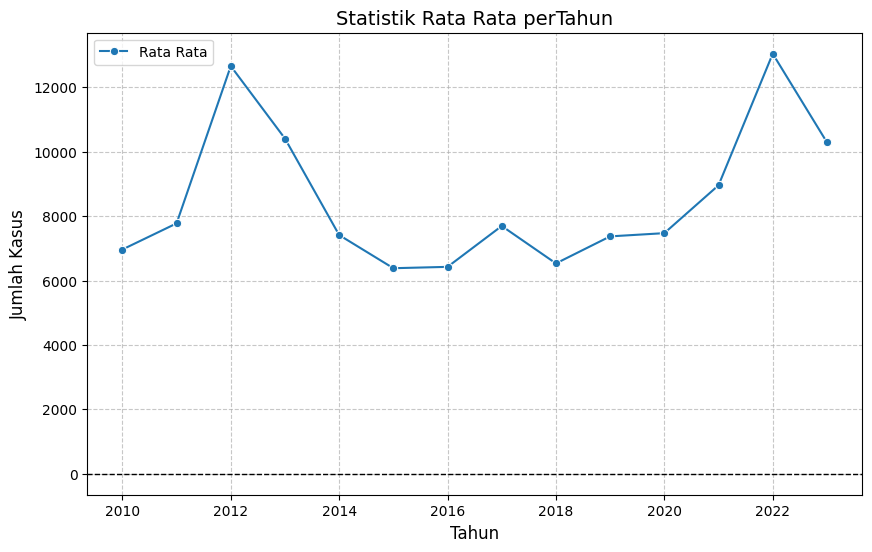

In [ ]:
malaria = pd.read_excel("malaria_data.xlsx", sheet_name="Malaria", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = malaria.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
malaria = malaria[malaria[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in malaria.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
malaria[tahun_cols] = (
    malaria[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = malaria[tahun_cols].mean()
statistik["median"] = malaria[tahun_cols].median()
statistik["Q1"] = malaria[tahun_cols].quantile(0.25)
statistik["Q3"] = malaria[tahun_cols].quantile(0.75)
statistik["min"] = malaria[tahun_cols].min()
statistik["max"] = malaria[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
# sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
# sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Kasus", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()

<ipython-input-4-35b7793fd455>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


           mean    median        Q1        Q3       min         max
2010   3.570858  0.523762  0.161423  2.000373  0.000000   49.984088
2011   3.194746  1.323390  0.188546  2.304392  0.000000   32.080616
2012   5.103533  0.865502  0.192336  2.471358  0.000000   56.219628
2013   3.919387  0.494432  0.232204  1.299656  0.000000   42.654230
2014   2.540328  0.438146  0.104687  0.922093  0.002367   29.570346
2015   2.631459  0.418065  0.087277  0.680279  0.000644   31.930462
2016   2.092087  0.169405  0.036683  0.480957  0.001429   45.851463
2017   2.560884  0.124323  0.033613  0.347205  0.002723   59.000331
2018   2.063525  0.100754  0.021976  0.297266  0.003718   52.992813
2019   2.281272  0.071002  0.017398  0.196919  0.002553   64.030974
2020   2.326305  0.061379  0.013576  0.143758  0.000456   63.119027
2021   2.704084  0.061084  0.010734  0.121330  0.000992   80.053388
2022   3.905258  0.079986  0.020279  0.207111  0.004544  113.067277
2023  11.454232  0.163106  0.017400  0.798345  0

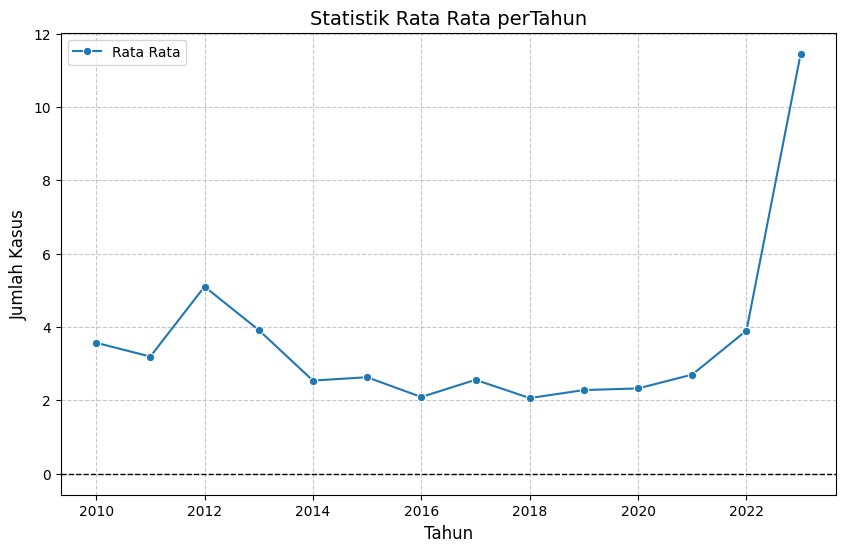

In [ ]:
malaria_per1000 = pd.read_excel("malaria_data.xlsx", sheet_name="malaria per1000 penduduk", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = malaria_per1000.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
malaria_per1000 = malaria_per1000[malaria_per1000[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in malaria_per1000.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
malaria_per1000[tahun_cols] = (
    malaria_per1000[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = malaria_per1000[tahun_cols].mean()
statistik["median"] = malaria_per1000[tahun_cols].median()
statistik["Q1"] = malaria_per1000[tahun_cols].quantile(0.25)
statistik["Q3"] = malaria_per1000[tahun_cols].quantile(0.75)
statistik["min"] = malaria_per1000[tahun_cols].min()
statistik["max"] = malaria_per1000[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
# sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
# sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Kasus", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()

             mean  median       Q1       Q3    min      max
2010  4729.878788  1507.0   589.00  4997.00    6.0  26020.0
2011  2110.709677  1416.0   382.00  2385.00   11.0  13836.0
2012  2734.696970  1547.0   967.00  3243.00   18.0  19663.0
2013  3409.424242  1369.0   638.00  3593.00   33.0  23118.0
2014  2951.382353  1312.5   543.25  2977.50   12.0  18116.0
2015  3813.235294  1540.0   721.75  3771.50   66.0  21237.0
2016  6005.117647  2618.0  1073.75  6220.00  105.0  36631.0
2017  2011.970588  1119.5   509.25  2560.75   37.0  10016.0
2018  1929.470588  1268.5   648.00  2364.25  110.0   8732.0
2019  4062.558824  2383.5  1513.25  4109.25  236.0  23483.0
2020  3185.382353  1760.5   894.50  3494.75   77.0  22613.0
2021  2162.294118   951.0   359.25  2639.25   98.0  23959.0
2022  4213.705882  2185.0  1093.25  4502.50   96.0  36608.0
2023  3018.947368  2041.0   830.00  3795.50    0.0  19328.0


<ipython-input-5-73f279bf5657>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


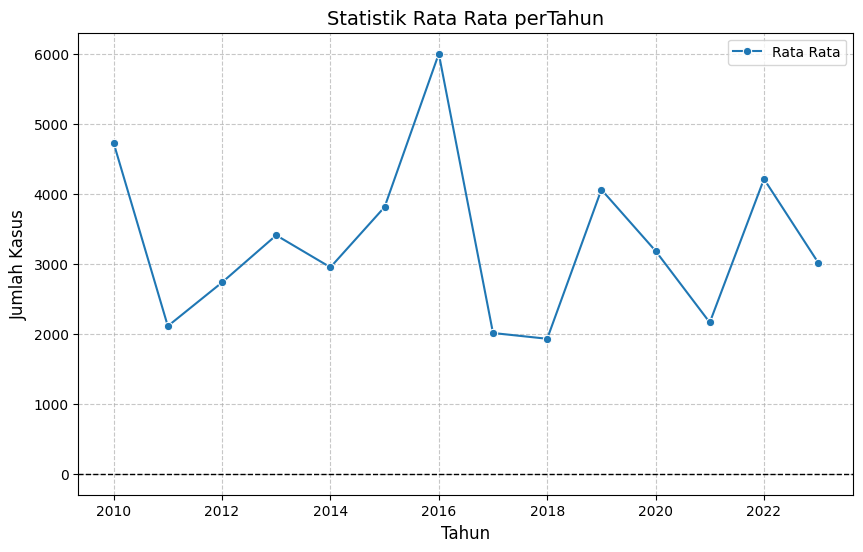

In [ ]:
DBD = pd.read_excel("malaria_data.xlsx", sheet_name="DBD", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = DBD.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
DBD = DBD[DBD[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in DBD.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
DBD[tahun_cols] = (
    DBD[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = DBD[tahun_cols].mean()
statistik["median"] = DBD[tahun_cols].median()
statistik["Q1"] = DBD[tahun_cols].quantile(0.25)
statistik["Q3"] = DBD[tahun_cols].quantile(0.75)
statistik["min"] = DBD[tahun_cols].min()
statistik["max"] = DBD[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
# sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
# sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Kasus", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()

<ipython-input-6-ae9cca3b8e1b>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


          mean    median        Q1        Q3       min       max
2010  0.609289  0.448968  0.225540  0.684707  0.003913  3.006356
2011  0.298374  0.229723  0.140027  0.452458  0.006981  0.761632
2012  0.404364  0.372143  0.215148  0.582419  0.022032  0.854160
2013  0.425468  0.389220  0.217057  0.508391  0.019844  1.645775
2014  0.455777  0.346231  0.200310  0.464621  0.007025  2.042181
2015  0.552382  0.454237  0.269606  0.586611  0.046250  2.577518
2016  0.897709  0.644854  0.454709  0.910712  0.117534  5.158963
2017  0.293806  0.285368  0.175975  0.376638  0.030595  1.059454
2018  0.341339  0.265707  0.184937  0.461130  0.058088  0.878088
2019  0.678352  0.588884  0.448999  0.804362  0.130902  2.390046
2020  0.508723  0.412173  0.216368  0.660532  0.042033  2.730993
2021  0.283141  0.240602  0.129062  0.440666  0.028503  0.809233
2022  0.585030  0.482938  0.329911  0.696015  0.052645  1.813075
2023  0.591969  0.384549  0.290924  0.687527  0.000000  1.864219


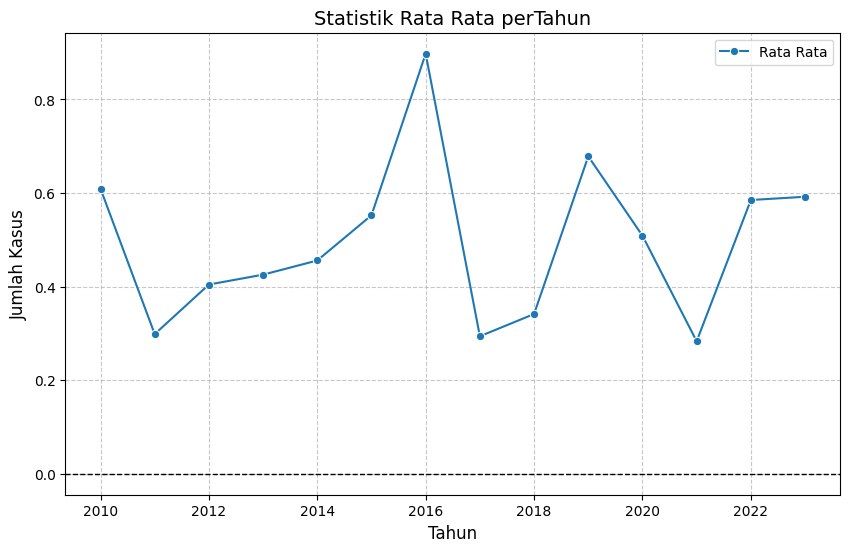

In [ ]:
DBD_per1000 = pd.read_excel("malaria_data.xlsx", sheet_name="DBD per1000 penduduk", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = DBD_per1000.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
DBD_per1000 = DBD_per1000[DBD_per1000[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in DBD_per1000.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
DBD_per1000[tahun_cols] = (
    DBD_per1000[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = DBD_per1000[tahun_cols].mean()
statistik["median"] = DBD_per1000[tahun_cols].median()
statistik["Q1"] = DBD_per1000[tahun_cols].quantile(0.25)
statistik["Q3"] = DBD_per1000[tahun_cols].quantile(0.75)
statistik["min"] = DBD_per1000[tahun_cols].min()
statistik["max"] = DBD_per1000[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
# sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
# sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Kasus", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()

Mean (Rata-rata)  : 0.102
Median (Nilai tengah): 0.053
Minimum (Nilai Terendah)  : -0.758
Maksimum (Nilai Tertinggi): 0.964
Quartile 1  : -0.111
Quartile 3  : 0.312


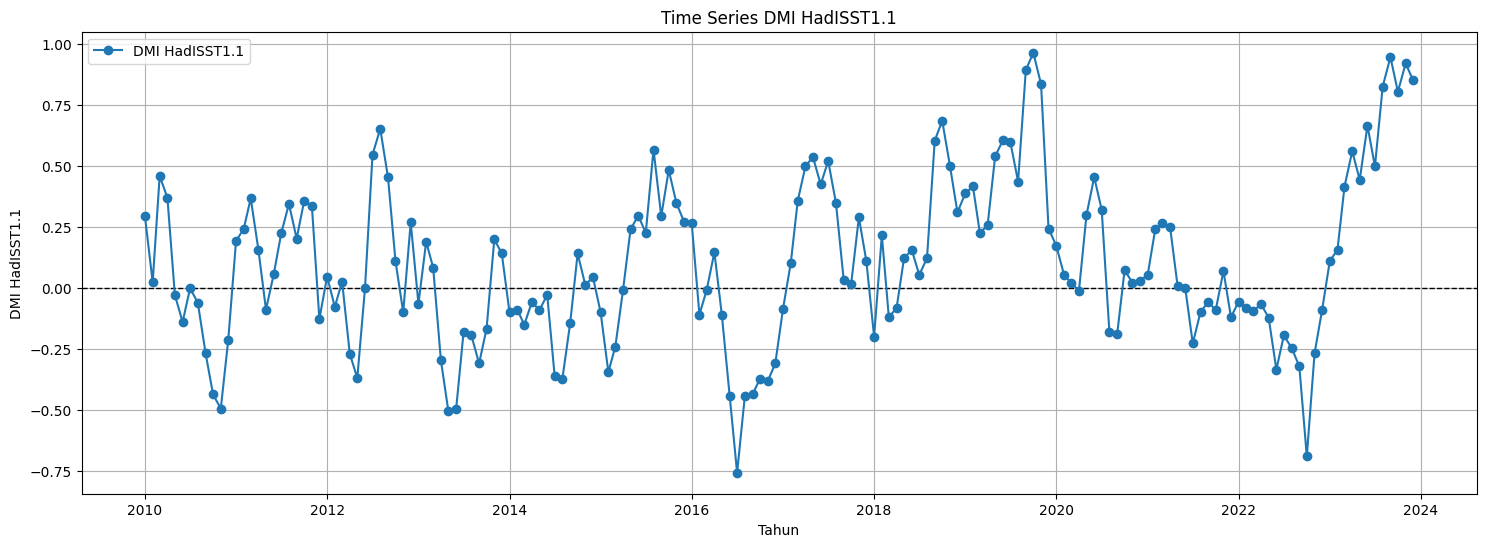

In [ ]:
dmi= pd.read_excel('DMI.xlsx')
# print(dmi)

# Mengambil kolom "DMI HadISST1.1"
dmi_values = dmi["DMI HadISST1.1"]

# Menghitung mean, median, dan modus
mean_dmi = np.mean(dmi_values)
median_dmi = np.median(dmi_values)
# mode_dmi = stats.mode(dmi_values, keepdims=True).mode[0]
min_dmi = np.min(dmi_values)
max_dmi = np.max(dmi_values)
q1_dmi = np.quantile(dmi_values, 0.25)
q3_dmi = np.quantile(dmi_values, 0.75)

# Menampilkan hasil
print(f"Mean (Rata-rata)  : {mean_dmi:.3f}")
print(f"Median (Nilai tengah): {median_dmi:.3f}")
# print(f"Modus (Nilai terbanyak): {mode_dmi:.3f}")
print(f"Minimum (Nilai Terendah)  : {min_dmi:.3f}")
print(f"Maksimum (Nilai Tertinggi): {max_dmi:.3f}")
print(f"Quartile 1  : {q1_dmi:.3f}")
print(f"Quartile 3  : {q3_dmi:.3f}")

# Konversi kolom 'Date' ke tipe datetime
dmi['Date'] = pd.to_datetime(dmi['Date'])

# Set kolom 'Date' sebagai index
dmi.set_index('Date', inplace=True)

# Plot time series
plt.figure(figsize=(18, 6))
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.plot(dmi.index, dmi["DMI HadISST1.1"], label="DMI HadISST1.1", marker='o', linestyle='-')
plt.xlabel("Tahun")
plt.ylabel("DMI HadISST1.1")
plt.title("Time Series DMI HadISST1.1")
plt.legend()
plt.grid(True)
plt.show()

          mean  median    min    max       Q1       Q3
Year                                                  
2010 -0.041667 -0.0460 -0.495  0.458 -0.22600  0.09075
2011  0.187833  0.2125 -0.128  0.367  0.12925  0.33800
2012  0.106917  0.0360 -0.370  0.652 -0.08350  0.31425
2013 -0.133750 -0.1740 -0.506  0.199 -0.30025  0.09750
2014 -0.100167 -0.0905 -0.372  0.141 -0.14650 -0.01850
2015  0.169167  0.2560 -0.345  0.567 -0.03100  0.30875
2016 -0.247167 -0.3410 -0.758  0.266 -0.43850 -0.08475
2017  0.262333  0.3190 -0.086  0.536  0.08425  0.44275
2018  0.196833  0.1385 -0.200  0.685  0.01900  0.35675
2019  0.533083  0.4875  0.224  0.964  0.35475  0.66250
2020  0.088167  0.0420 -0.190  0.454  0.01150  0.20425
2021  0.024167  0.0035 -0.228  0.266 -0.09300  0.11250
2022 -0.214333 -0.1585 -0.691 -0.056 -0.28225 -0.08975
2023  0.599417  0.6125  0.109  0.946  0.43600  0.83150


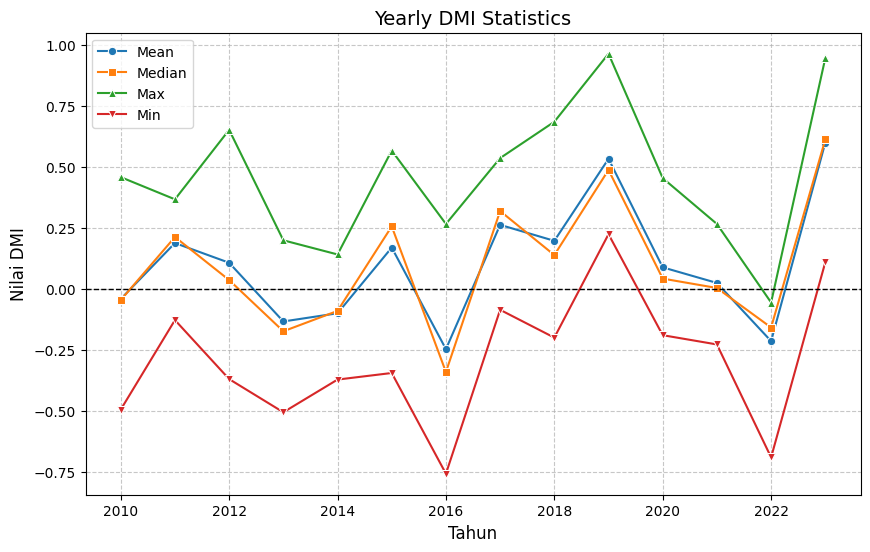

In [ ]:
dmi= pd.read_excel('DMI.xlsx')
# print(dmi)

# Pastikan kolom "Date" dalam format datetime
dmi['Date'] = pd.to_datetime(dmi['Date'])

# Tambahkan kolom "Year" dari "Date"
dmi["Year"] = dmi["Date"].dt.year

# Menghitung statistik tiap tahun
stats_tahunan = dmi.groupby("Year")["DMI HadISST1.1"].agg([
    ("mean", "mean"),
    ("median", "median"),
    ("min", "min"),
    ("max", "max"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
])

print(stats_tahunan)

# Plot line chart untuk statistik tahunan
# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=stats_tahunan.index, y=stats_tahunan["mean"], label="Mean", marker="o")
sns.lineplot(x=stats_tahunan.index, y=stats_tahunan["median"], label="Median", marker="s")
sns.lineplot(x=stats_tahunan.index, y=stats_tahunan["max"], label="Max", marker="^")
sns.lineplot(x=stats_tahunan.index, y=stats_tahunan["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Yearly DMI Statistics", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Nilai DMI", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()


Mean (Rata-rata)  : -0.060
Median (Nilai tengah): -0.320
Minimum (Nilai Terendah)  : -1.640
Maksimum (Nilai Tertinggi): 2.480
Quartile 1  : -0.700
Quartile 3  : 0.385


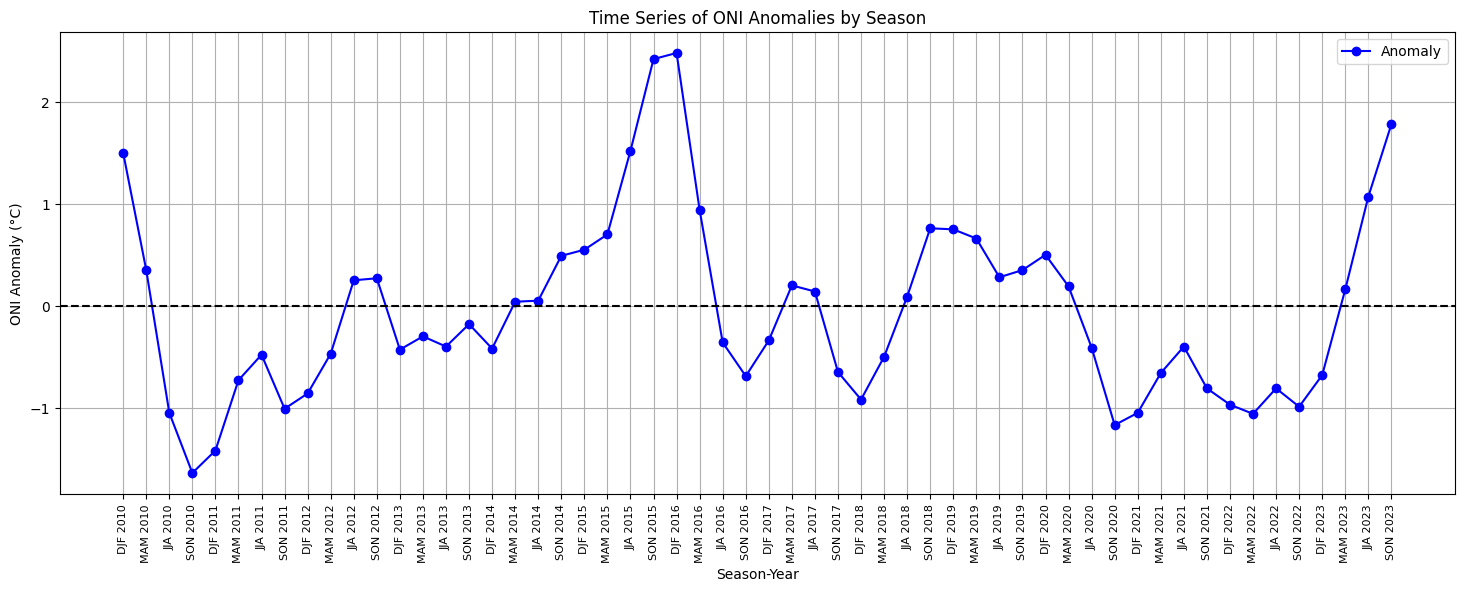

In [ ]:
oni= pd.read_excel('ONI_3.xlsx')
# print(oni)

# Mengambil kolom "ANOM"
oni_values = oni["ANOM"]

# Menghitung mean, median, dan modus
mean_oni = np.mean(oni_values)
median_oni = np.median(oni_values)
# mode_oni = stats.mode(oni_values, keepdims=True).mode[0]
min_oni = np.min(oni_values)
max_oni = np.max(oni_values)
q1_oni = np.quantile(oni_values, 0.25)
q3_oni = np.quantile(oni_values, 0.75)

# Menampilkan hasil
print(f"Mean (Rata-rata)  : {mean_oni:.3f}")
print(f"Median (Nilai tengah): {median_oni:.3f}")
# print(f"Modus (Nilai terbanyak): {mode_oni:.3f}")
print(f"Minimum (Nilai Terendah)  : {min_oni:.3f}")
print(f"Maksimum (Nilai Tertinggi): {max_oni:.3f}")
print(f"Quartile 1  : {q1_oni:.3f}")
print(f"Quartile 3  : {q3_oni:.3f}")

# PLOT ONI
# Define the correct order of seasons
season_order = ["DJF", "MAM", "JJA", "SON"]

# Create a new column combining season and year for x-axis labeling
oni["Season_Year"] = oni["SEAS"] + " " + oni["Year"].astype(str)

# Sort the data by year and season order
oni["SEAS"] = pd.Categorical(oni["SEAS"], categories=season_order, ordered=True)
oni = oni.sort_values(by=["Year", "SEAS"])

# Plot the anomaly time series
plt.figure(figsize=(18, 6))
plt.plot(oni["Season_Year"], oni["ANOM"], marker="o", linestyle="-", color="b", label="Anomaly")

# Formatting
plt.axhline(y=0, color="black", linestyle="--")  # Reference line at zero anomaly
plt.xlabel("Season-Year")
plt.ylabel("ONI Anomaly (°C)")
plt.title("Time Series of ONI Anomalies by Season")

# Set x-ticks to show only every 2nd month
plt.xticks(ticks=range(0, len(oni), 1), labels=oni["Season_Year"][::1], rotation=90, fontsize=8)
plt.legend()
plt.grid()

# Show the plot
plt.show()


        mean  median   min   max      Q1      Q3
Year                                            
2010 -0.2100  -0.350 -1.64  1.50 -1.1975  0.6375
2011 -0.9100  -0.870 -1.42 -0.48 -1.1125 -0.6675
2012 -0.2025  -0.110 -0.86  0.27 -0.5675  0.2550
2013 -0.3275  -0.350 -0.43 -0.18 -0.4075 -0.2700
2014  0.0400   0.045 -0.42  0.49 -0.0750  0.1600
2015  1.2975   1.110  0.55  2.42  0.6625  1.7450
2016  0.5925   0.290 -0.69  2.48 -0.4425  1.3250
2017 -0.1625  -0.100 -0.65  0.20 -0.4175  0.1550
2018 -0.1425  -0.205 -0.92  0.76 -0.6050  0.2575
2019  0.5100   0.505  0.28  0.75  0.3325  0.6825
2020 -0.2225  -0.110 -1.17  0.50 -0.6000  0.2675
2021 -0.7300  -0.735 -1.05 -0.40 -0.8700 -0.5950
2022 -0.9575  -0.980 -1.06 -0.81 -1.0075 -0.9300
2023  0.5825   0.615 -0.68  1.78 -0.0500  1.2475


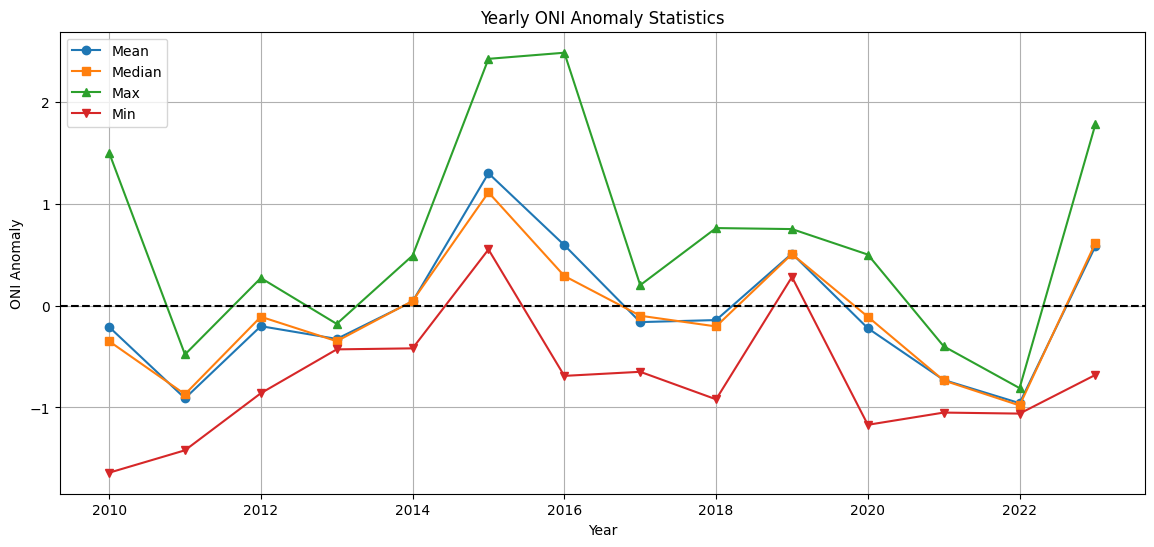

In [ ]:
oni= pd.read_excel('ONI_3.xlsx')
# print(oni)

# Define the correct order of seasons
season_order = ["DJF", "MAM", "JJA", "SON"]

# Create a new column combining season and year for x-axis labeling
oni["Season_Year"] = oni["SEAS"] + " " + oni["Year"].astype(str)

# Sort the data by year and season order
oni["SEAS"] = pd.Categorical(oni["SEAS"], categories=season_order, ordered=True)
oni = oni.sort_values(by=["Year", "SEAS"])

# Compute yearly statistics
stats = oni.groupby("Year")["ANOM"].agg([
    ("mean", "mean"),
    ("median", "median"),
    ("min", "min"),
    ("max", "max"),
    ("Q1", lambda x: x.quantile(0.25)),
    ("Q3", lambda x: x.quantile(0.75))
])

print(stats)

# Plot mean, median, min, and max anomaly per year
plt.figure(figsize=(14, 6))
plt.plot(stats.index, stats["mean"], label="Mean", marker="o")
plt.plot(stats.index, stats["median"], label="Median", marker="s")
plt.plot(stats.index, stats["max"], label="Max", marker="^")
plt.plot(stats.index, stats["min"], label="Min", marker="v")
# Formatting
plt.axhline(y=0, color="black", linestyle="--")  # Reference line at zero anomaly
plt.xlabel("Year")
plt.ylabel("ONI Anomaly")
plt.title("Yearly ONI Anomaly Statistics")
plt.legend()
plt.grid()

# Show the plot
plt.show()

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

drive.mount('/content/drive')

!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (Standarisasi).xlsx" "./malaria_data.xlsx"
malaria_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi Malaria", header=0)
iod_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi IOD(DMI)", header=0)
enso_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi ENSO(ONI)", header=0)
# df= pd.read_excel('malaria_data.xlsx')
# print(df.columns)

# Extract years from malaria data (columns 4 onward)
years = malaria_df.columns[3:].astype(str)
x = np.arange(len(years))  # e.g. [0, 1, ..., 13] for regression x-axis

# Extract IOD and ENSO time series (row 0, columns 2 onward)
iod = iod_df.iloc[0, 1:].values
# print(iod)
enso = enso_df.iloc[0, 1:].values

# 🌍 Compute global y-limits (FIXED)
malaria_values_all = malaria_df.iloc[:, 3:].apply(pd.to_numeric, errors='coerce').values.flatten()
iod = pd.to_numeric(iod, errors='coerce')   # Convert to numeric
enso = pd.to_numeric(enso, errors='coerce') # Convert to numeric

# Combine and ensure all are float type
combined = np.concatenate([malaria_values_all.astype(float), iod.astype(float), enso.astype(float)])
valid = combined[~np.isnan(combined)]

# Add padding to min and max
min_y, max_y = valid.min() - 0.5, valid.max() + 0.5


# Set output directory in Google Drive
output_dir = '/content/drive/MyDrive/DATA/province_plots_Malaria'
os.makedirs(output_dir, exist_ok=True)

# Plotting function for each province
def plot_province(province_name, malaria_values):
    malaria_values = pd.to_numeric(malaria_values, errors='coerce')

    # Linear regression for malaria trend
    coeffs = np.polyfit(x, malaria_values, 1)
    trend_line = np.poly1d(coeffs)(x)

    #plotting
    plt.figure(figsize=(10, 6))
    plt.plot(years, malaria_values, label='Malaria', color='blue', linewidth=2)
    plt.plot(years, iod, label='IOD (DMI)', color='orange', linestyle='--', linewidth=2)
    plt.plot(years, enso, label='ENSO (ONI)', color='gray', linestyle='-.', linewidth=2)
    # plt.plot(years, trend_line, label='Malaria Trend (regression)', color='red', linestyle=':', linewidth=2)

    plt.title(f'Time Series Malaria - {province_name.title()}', fontsize=14)
    plt.xlabel('Tahun', fontsize=12)
    plt.ylabel('Standarisasi', fontsize=12)

    # 🔍 Add legend with location and font size
    plt.legend(loc='best', fontsize=10)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylim(min_y, max_y)
    plt.tight_layout()

    filename = f"{output_dir}/time_series_{province_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()

# Generate and save plots for all provinces
for _, row in malaria_df.iterrows():
    province = row['Nama Provinsi']
    malaria_values = row[3:].values
    plot_province(province, malaria_values)

print(f"✅ All plots saved in: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All plots saved in: /content/drive/MyDrive/DATA/province_plots_Malaria


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (Standarisasi).xlsx" "./malaria_data.xlsx"
DBD_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi DBD", header=0)
iod_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi IOD(DMI)", header=0)
enso_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi ENSO(ONI)", header=0)
# df= pd.read_excel('DBD_data.xlsx')
# print(df.columns)

# Extract years from DBD data (columns 4 onward)
years = DBD_df.columns[3:].astype(str)
x = np.arange(len(years))  # e.g. [0, 1, ..., 13] for regression x-axis

# Extract IOD and ENSO time series (row 0, columns 2 onward)
iod = iod_df.iloc[0, 1:].values
enso = enso_df.iloc[0, 1:].values

# 🌍 Compute global y-limits (FIXED)
DBD_values_all = DBD_df.iloc[:, 3:].apply(pd.to_numeric, errors='coerce').values.flatten()
iod = pd.to_numeric(iod, errors='coerce')   # Convert to numeric
enso = pd.to_numeric(enso, errors='coerce') # Convert to numeric

# Combine and ensure all are float type
combined = np.concatenate([DBD_values_all.astype(float), iod.astype(float), enso.astype(float)])
valid = combined[~np.isnan(combined)]

# Add padding to min and max
min_y, max_y = valid.min() - 0.5, valid.max() + 0.5

# Set output directory in Google Drive
output_dir = '/content/drive/MyDrive/DATA/province_plots_DBD'
os.makedirs(output_dir, exist_ok=True)

# Plotting function for each province
def plot_province(province_name, DBD_values):
    DBD_values = pd.to_numeric(DBD_values, errors='coerce')

    # Linear regression for DBD trend
    coeffs = np.polyfit(x, DBD_values, 1)
    trend_line = np.poly1d(coeffs)(x)

    #plot
    fig, axes = plt.subplots(figsize=(10,6))
    plt.plot(years, DBD_values, label='DBD', color='blue', linewidth=2)
    plt.plot(years, iod, label='IOD (DMI)', color='orange', linestyle='--', linewidth=2)
    plt.plot(years, enso, label='ENSO (ONI)', color='gray', linestyle='-.', linewidth=2)
    # plt.plot(years, trend_line, label='Malaria Trend (regression)', color='red', linestyle=':', linewidth=2)

    plt.title(f'Time Series DBD - {province_name.title()}', fontsize=14)
    plt.xlabel('Tahun', fontsize=12)
    plt.ylabel('Standarisasi', fontsize=12)

    # 🔍 Add legend with location and font size
    plt.legend(loc='best', fontsize=10)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylim(min_y, max_y)
    plt.tight_layout()

    filename = f"{output_dir}/time_series_{province_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()

# Generate and save plots for all provinces
for _, row in DBD_df.iterrows():
    province = row['Nama Provinsi']
    DBD_values = row[3:].values
    plot_province(province, DBD_values)

print(f"✅ All plots saved in: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All plots saved in: /content/drive/MyDrive/DATA/province_plots_DBD


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Copy and read Excel file
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (Standarisasi).xlsx" "./malaria_data.xlsx"
malaria_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi Malaria", header=0)
iod_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi IOD(DMI)", header=0)

# Extract year columns and IOD time series
years = malaria_df.columns[3:]
iod_values = pd.to_numeric(iod_df.iloc[0, 1:].values, errors='coerce')

# Set output folder in Drive
output_dir = "/content/drive/MyDrive/DATA/province_regression_plots_malaria_IOD"
os.makedirs(output_dir, exist_ok=True)

# Loop through each province
for idx, row in malaria_df.iterrows():
    province = row['Nama Provinsi']
    malaria_values = pd.to_numeric(row[3:].values, errors='coerce')

    # Build DataFrame for regression
    df = pd.DataFrame({
        'IOD (DMI)': iod_values,
        'Malaria': malaria_values
    }).dropna()

    if len(df) < 2:
        print(f"Skipping {province} — not enough data.")
        continue

    # Plot regression
    plt.figure(figsize=(8, 6))
    sns.regplot(x='IOD (DMI)', y='Malaria', data=df, ci=None,
                # scatter_kws={'alpha':0.6},
                line_kws={"color": "red"}
                )
    plt.title(f"Regression: Malaria vs IOD (DMI)\n{province}")
    plt.xlabel("Standarisasi IOD (DMI)")
    plt.ylabel("Standarisasi Malaria")
    plt.grid(True)
    plt.ylim(min_y, max_y)
    plt.tight_layout()

    # Save to Drive
    filename = f"{output_dir}/regression_malaria_iod_{province.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()

print(f"✅ All regression plots saved to: {output_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Skipping KALIMANTAN UTARA — not enough data.
Skipping PAPUA BARAT DAYA — not enough data.
Skipping PAPUA SELATAN — not enough data.
Skipping PAPUA TENGAH — not enough data.
Skipping PAPUA PEGUNUNGAN — not enough data.
✅ All regression plots saved to: /content/drive/MyDrive/DATA/province_regression_plots_malaria_IOD


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Copy and read Excel file
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (Standarisasi).xlsx" "./malaria_data.xlsx"
malaria_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi Malaria", header=0)
ENSO_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi ENSO(ONI)", header=0)

# Extract year columns and ENSO time series
years = malaria_df.columns[3:]
ENSO_values = pd.to_numeric(ENSO_df.iloc[0, 1:].values, errors='coerce')

# Set output folder in Drive
output_dir = "/content/drive/MyDrive/DATA/province_regression_plots_malaria_ENSO"
os.makedirs(output_dir, exist_ok=True)

# Loop through each province
for idx, row in malaria_df.iterrows():
    province = row['Nama Provinsi']
    malaria_values = pd.to_numeric(row[3:].values, errors='coerce')

    # Build DataFrame for regression
    df = pd.DataFrame({
        'ENSO (ONI)': ENSO_values,
        'Malaria': malaria_values
    }).dropna()

    if len(df) < 2:
        print(f"Skipping {province} — not enough data.")
        continue

    # Plot regression
    plt.figure(figsize=(8, 6))
    sns.regplot(x='ENSO (ONI)', y='Malaria', data=df, ci=None,
                # scatter_kws={'alpha':0.6},
                line_kws={"color": "red"})
    plt.title(f"Regression: Malaria vs ENSO (ONI)\n{province}")
    plt.xlabel("Standarisasi ENSO (ONI)")
    plt.ylabel("Standarisasi Malaria")
    plt.grid(True)
    plt.ylim(min_y, max_y)
    plt.tight_layout()

    # Save to Drive
    filename = f"{output_dir}/regression_malaria_ENSO_{province.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()

print(f"✅ All regression plots saved to: {output_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Skipping KALIMANTAN UTARA — not enough data.
Skipping PAPUA BARAT DAYA — not enough data.
Skipping PAPUA SELATAN — not enough data.
Skipping PAPUA TENGAH — not enough data.
Skipping PAPUA PEGUNUNGAN — not enough data.
✅ All regression plots saved to: /content/drive/MyDrive/DATA/province_regression_plots_malaria_ENSO


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Copy and read Excel file
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (Standarisasi).xlsx" "./malaria_data.xlsx"
DBD_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi DBD", header=0)
iod_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi IOD(DMI)", header=0)

# Extract year columns and IOD time series
years = DBD_df.columns[3:]
iod_values = pd.to_numeric(iod_df.iloc[0, 1:].values, errors='coerce')

# Set output folder in Drive
output_dir = "/content/drive/MyDrive/DATA/province_regression_plots_DBD_IOD"
os.makedirs(output_dir, exist_ok=True)

# Loop through each province
for idx, row in DBD_df.iterrows():
    province = row['Nama Provinsi']
    DBD_values = pd.to_numeric(row[3:].values, errors='coerce')

    # Build DataFrame for regression
    df = pd.DataFrame({
        'IOD (DMI)': iod_values,
        'DBD': DBD_values
    }).dropna()

    if len(df) < 2:
        print(f"Skipping {province} — not enough data.")
        continue

    # Plot regression
    plt.figure(figsize=(8, 6))
    sns.regplot(x='IOD (DMI)', y='DBD', data=df,ci=None,
                # scatter_kws={'alpha':0.6},
                line_kws={"color": "red"})
    plt.title(f"Regression: DBD vs IOD (DMI)\n{province}")
    plt.xlabel("Standarisasi IOD (DMI)")
    plt.ylabel("Standarisasi DBD")
    plt.grid(True)
    plt.ylim(min_y, max_y)
    plt.tight_layout()

    # Save to Drive
    filename = f"{output_dir}/regression_DBD_iod_{province.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()

print(f"✅ All regression plots saved to: {output_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Skipping KALIMANTAN UTARA — not enough data.
Skipping PAPUA BARAT DAYA — not enough data.
Skipping PAPUA SELATAN — not enough data.
Skipping PAPUA TENGAH — not enough data.
Skipping PAPUA PEGUNUNGAN — not enough data.
✅ All regression plots saved to: /content/drive/MyDrive/DATA/province_regression_plots_DBD_IOD


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Copy and read Excel file
!cp "/content/drive/MyDrive/DATA/Kasus malaria & dbd perprovinsi 2010-2023 (Standarisasi).xlsx" "./malaria_data.xlsx"
DBD_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi DBD", header=0)
ENSO_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi ENSO(ONI)", header=0)

# Extract year columns and ENSO time series
years = DBD_df.columns[3:]
ENSO_values = pd.to_numeric(ENSO_df.iloc[0, 1:].values, errors='coerce')

# Set output folder in Drive
output_dir = "/content/drive/MyDrive/DATA/province_regression_plots_DBD_ENSO"
os.makedirs(output_dir, exist_ok=True)

# Loop through each province
for idx, row in DBD_df.iterrows():
    province = row['Nama Provinsi']
    DBD_values = pd.to_numeric(row[3:].values, errors='coerce')

    # Build DataFrame for regression
    df = pd.DataFrame({
        'ENSO (ONI)': ENSO_values,
        'DBD': DBD_values
    }).dropna()

    if len(df) < 2:
        print(f"Skipping {province} — not enough data.")
        continue

    # Plot regression
    plt.figure(figsize=(8, 6))
    sns.regplot(x='ENSO (ONI)', y='DBD', data=df,ci=None,
                # scatter_kws={'alpha':0.6},
                line_kws={"color": "red"})
    plt.title(f"Regression: DBD vs ENSO (ONI)\n{province}")
    plt.xlabel("Standarisasi ENSO (ONI)")
    plt.ylabel("Standarisasi DBD")
    plt.grid(True)
    plt.ylim(min_y, max_y)
    plt.tight_layout()

    # Save to Drive
    filename = f"{output_dir}/regression_DBD_ENSO_{province.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()

print(f"✅ All regression plots saved to: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Skipping KALIMANTAN UTARA — not enough data.
Skipping PAPUA BARAT DAYA — not enough data.
Skipping PAPUA SELATAN — not enough data.
Skipping PAPUA TENGAH — not enough data.
Skipping PAPUA PEGUNUNGAN — not enough data.
✅ All regression plots saved to: /content/drive/MyDrive/DATA/province_regression_plots_DBD_ENSO


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Load data
malaria_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi Malaria")
enso_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi ENSO(ONI)")

# Get ENSO data from first row (excluding the first column)
enso = pd.to_numeric(enso_df.iloc[0, 1:], errors='coerce')

# Get years from malaria data (from column 4 onward)
years = malaria_df.columns[3:]

# Store results
regression_results = []

# Loop through provinces
for _, row in malaria_df.iterrows():
    province = row['Nama Provinsi']
    malaria = pd.to_numeric(row[3:].values, errors='coerce')

    # Mask valid data points (not NaN)
    mask = ~np.isnan(malaria) & ~np.isnan(enso)
    if np.sum(mask) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(enso[mask], malaria[mask])
        regression_results.append({
            "Provinsi": province,
            "Slope": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "p-value": p_value,
            "Std. Error": std_err
        })
    else:
        regression_results.append({
            "Provinsi": province,
            "Slope": np.nan,
            "Intercept": np.nan,
            "R-squared": np.nan,
            "p-value": np.nan,
            "Std. Error": np.nan
        })

# Convert to DataFrame
regression_df = pd.DataFrame(regression_results)

# Print or save
print(regression_df.sort_values(by='R-squared', ascending=False))

# Optional: save to CSV
regression_df.to_csv("/content/drive/MyDrive/DATA/regression_stats_malaria_enso.csv", index=False)


                Provinsi     Slope     Intercept  R-squared   p-value  \
26      SULAWESI SELATAN -0.499476 -7.853402e-11   0.249476  0.068992   
29        SULAWESI BARAT -0.389323 -3.066597e-11   0.151573  0.168845   
19      KALIMANTAN BARAT -0.378977  1.650165e-11   0.143623  0.181452   
22      KALIMANTAN TIMUR -0.365880 -8.541999e-11   0.133868  0.198257   
12           JAWA TENGAH  0.364224  4.744459e-11   0.132659  0.200449   
0                   ACEH -0.324357 -1.459689e-11   0.105207  0.257881   
3                   RIAU -0.316847 -2.620331e-11   0.100392  0.269702   
7                LAMPUNG  0.314698  5.819273e-11   0.099035  0.273141   
20     KALIMANTAN TENGAH -0.299729 -2.140918e-11   0.089838  0.297825   
5       SUMATERA SELATAN  0.297750  2.841072e-11   0.088655  0.301183   
11            JAWA BARAT -0.260648 -8.290343e-11   0.067937  0.368104   
24        SULAWESI UTARA -0.248772 -3.919796e-11   0.061887  0.391093   
25       SULAWESI TENGAH -0.247431  1.946921e-11   

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Load data
malaria_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi Malaria")
iod_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi IOD(DMI)")

# Get iod data from first row (excluding the first column)
iod = pd.to_numeric(iod_df.iloc[0, 1:], errors='coerce')

# Get years from malaria data (from column 4 onward)
years = malaria_df.columns[3:]

# Store results
regression_results = []

# Loop through provinces
for _, row in malaria_df.iterrows():
    province = row['Nama Provinsi']
    malaria = pd.to_numeric(row[3:].values, errors='coerce')

    # Mask valid data points (not NaN)
    mask = ~np.isnan(malaria) & ~np.isnan(iod)
    if np.sum(mask) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(iod[mask], malaria[mask])
        regression_results.append({
            "Provinsi": province,
            "Slope": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "p-value": p_value,
            "Std. Error": std_err
        })
    else:
        regression_results.append({
            "Provinsi": province,
            "Slope": np.nan,
            "Intercept": np.nan,
            "R-squared": np.nan,
            "p-value": np.nan,
            "Std. Error": np.nan
        })

# Convert to DataFrame
regression_df = pd.DataFrame(regression_results)

# Print or save
print(regression_df.sort_values(by='R-squared', ascending=False))

# Optional: save to CSV
regression_df.to_csv("/content/drive/MyDrive/DATA/regression_stats_malaria_iod.csv", index=False)

                Provinsi     Slope     Intercept  R-squared   p-value  \
16                  BALI  0.480804 -3.461486e-11   0.231173  0.081792   
10           DKI JAKARTA  0.446805 -1.962637e-11   0.199635  0.109227   
5       SUMATERA SELATAN -0.442223 -4.380691e-13   0.195561  0.113353   
12           JAWA TENGAH -0.417955  1.426365e-11   0.174686  0.136985   
31          MALUKU UTARA -0.407785 -5.556201e-11   0.166289  0.147798   
30                MALUKU -0.391064  4.388981e-13   0.152931  0.166782   
1         SUMATERA UTARA -0.368145  2.368903e-11   0.135530  0.195283   
22      KALIMANTAN TIMUR  0.343055 -5.340482e-11   0.117687  0.229833   
18   NUSA TENGGARA TIMUR -0.333754 -5.000719e-11   0.111392  0.243539   
6               BENGKULU -0.328957 -3.496385e-12   0.108212  0.250799   
2         SUMATERA BARAT -0.306421 -6.668147e-11   0.093894  0.286635   
17   NUSA TENGGARA BARAT -0.278619  2.758077e-11   0.077629  0.334751   
0                   ACEH -0.261863  4.082401e-12   

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Load data
DBD_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi DBD")
enso_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi ENSO(ONI)")

# Get ENSO data from first row (excluding the first column)
enso = pd.to_numeric(enso_df.iloc[0, 1:], errors='coerce')

# Get years from DBD data (from column 4 onward)
years = DBD_df.columns[3:]

# Store results
regression_results = []

# Loop through provinces
for _, row in DBD_df.iterrows():
    province = row['Nama Provinsi']
    DBD = pd.to_numeric(row[3:].values, errors='coerce')

    # Mask valid data points (not NaN)
    mask = ~np.isnan(DBD) & ~np.isnan(enso)
    if np.sum(mask) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(enso[mask], DBD[mask])
        regression_results.append({
            "Provinsi": province,
            "Slope": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "p-value": p_value,
            "Std. Error": std_err
        })
    else:
        regression_results.append({
            "Provinsi": province,
            "Slope": np.nan,
            "Intercept": np.nan,
            "R-squared": np.nan,
            "p-value": np.nan,
            "Std. Error": np.nan
        })

# Convert to DataFrame
regression_df = pd.DataFrame(regression_results)

# Print or save
print(regression_df.sort_values(by='R-squared', ascending=False))

# Optional: save to CSV
regression_df.to_csv("/content/drive/MyDrive/DATA/regression_stats_DBD_enso.csv", index=False)

                Provinsi     Slope     Intercept  R-squared   p-value  \
21    KALIMANTAN SELATAN  0.852454  5.946096e-11   0.726677  0.000108   
34                 PAPUA  0.668359 -7.202808e-02   0.408433  0.018694   
27     SULAWESI TENGGARA  0.620847  2.006053e-11   0.385451  0.017817   
22      KALIMANTAN TIMUR  0.602614  7.329580e-12   0.363144  0.022558   
5       SUMATERA SELATAN  0.548062  2.843300e-11   0.300372  0.042454   
20     KALIMANTAN TENGAH  0.520280  3.716285e-11   0.270691  0.056488   
14            JAWA TIMUR  0.501778  3.584127e-11   0.251781  0.067520   
3                   RIAU  0.476850  7.477503e-11   0.227386  0.084703   
16                  BALI  0.475322  5.466583e-11   0.225931  0.085847   
29        SULAWESI BARAT  0.460903 -1.564972e-11   0.212432  0.097181   
30                MALUKU  0.378520  5.560854e-11   0.143277  0.182022   
26      SULAWESI SELATAN  0.363725  1.526606e-11   0.132296  0.201113   
13         DI YOGYAKARTA  0.363548  4.739629e-11   

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Load data
DBD_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi DBD")
iod_df = pd.read_excel("malaria_data.xlsx", sheet_name="Standarisasi IOD(DMI)")

# Get iod data from first row (excluding the first column)
iod = pd.to_numeric(iod_df.iloc[0, 1:], errors='coerce')

# Get years from DBD data (from column 4 onward)
years = DBD_df.columns[3:]

# Store results
regression_results = []

# Loop through provinces
for _, row in DBD_df.iterrows():
    province = row['Nama Provinsi']
    DBD = pd.to_numeric(row[3:].values, errors='coerce')

    # Mask valid data points (not NaN)
    mask = ~np.isnan(DBD) & ~np.isnan(iod)
    if np.sum(mask) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(iod[mask], DBD[mask])
        regression_results.append({
            "Provinsi": province,
            "Slope": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "p-value": p_value,
            "Std. Error": std_err
        })
    else:
        regression_results.append({
            "Provinsi": province,
            "Slope": np.nan,
            "Intercept": np.nan,
            "R-squared": np.nan,
            "p-value": np.nan,
            "Std. Error": np.nan
        })

# Convert to DataFrame
regression_df = pd.DataFrame(regression_results)

# Print or save
print(regression_df.sort_values(by='R-squared', ascending=False))

# Optional: save to CSV
regression_df.to_csv("/content/drive/MyDrive/DATA/regression_stats_DBD_iod.csv", index=False)

                Provinsi     Slope     Intercept  R-squared   p-value  \
32           PAPUA BARAT  0.617631  1.675737e-02   0.406881  0.018992   
19      KALIMANTAN BARAT  0.590631 -1.844637e-11   0.348845  0.026154   
20     KALIMANTAN TENGAH  0.570474  9.779520e-12   0.325441  0.033147   
11            JAWA BARAT -0.545086  5.655668e-12   0.297119  0.043820   
26      SULAWESI SELATAN -0.536148 -1.990538e-11   0.287455  0.048116   
10           DKI JAKARTA -0.521644 -1.251386e-11   0.272112  0.055730   
9              KEP. RIAU -0.465093 -1.229730e-10   0.216312  0.093786   
15                BANTEN -0.464551  1.632204e-11   0.215808  0.094221   
12           JAWA TENGAH -0.464445 -2.224758e-11   0.215710  0.094305   
31          MALUKU UTARA  0.452942 -3.230674e-11   0.205157  0.103864   
13         DI YOGYAKARTA -0.445993  1.378298e-11   0.198910  0.109951   
16                  BALI -0.414953  1.360081e-11   0.172186  0.140120   
28             GORONTALO  0.341541  2.799784e-11   

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-7-3268721079>:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


             mean     median       Q1         Q3      min      max
2010  2904.667348  2954.6100  2389.90  3256.4200  1606.12  4282.60
2011  2355.247348  2322.9800  1805.22  2788.2225  1516.89  3686.61
2012  2301.520000  2092.1400  1845.94  2706.3600  1405.22  4157.15
2013  2701.878712  2717.7800  2303.38  3039.2900  1772.38  3849.05
2014  2181.097121  2149.5250  1809.12  2481.0300  1319.31  3550.36
2015  1844.445227  1787.4400  1316.12  2156.9600  1008.20  3187.82
2016  2670.491667  2564.6100  2238.07  2888.3900  1232.75  4761.22
2017  2717.942273  2577.1000  2236.28  3183.7500  1514.84  3880.65
2018  2239.701970  2126.2100  1821.12  2564.4500  1254.21  3623.23
2019  1942.095076  1883.5300  1530.43  2466.9900   884.87  3351.36
2020  2853.375455  2795.7550  2479.28  3234.9300  1142.53  4457.27
2021  2955.954167  2875.6625  2524.86  3164.4200  1971.67  4217.63
2022  2902.770000  2844.6200  2449.43  3332.7900  1859.14  4372.13
2023  2140.420303  2050.5200  1725.41  2423.3800  1211.43  407

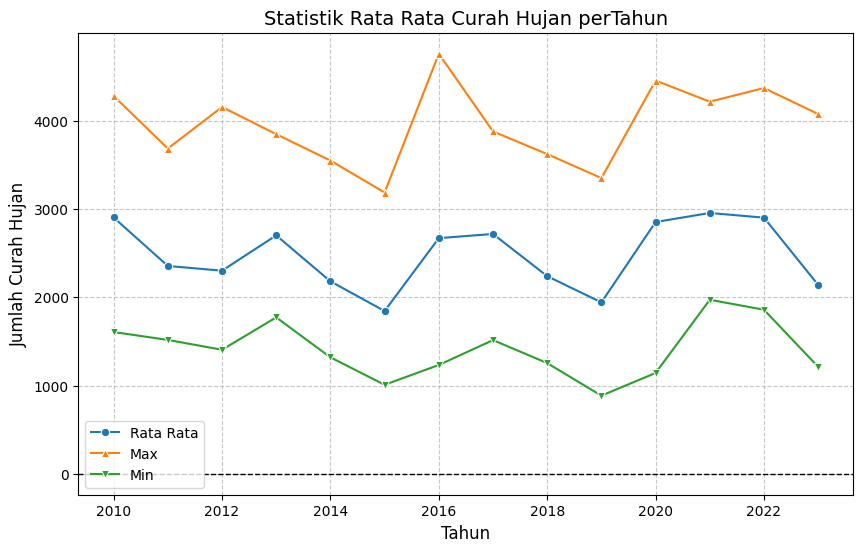

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/DATA/Iklim Lokal & Standarisasi.xlsx" "./Iklim_data.xlsx"

Curah = pd.read_excel("Iklim_data.xlsx", sheet_name="Curah Hujan", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = Curah.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
Curah = Curah[Curah[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in Curah.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
Curah[tahun_cols] = (
    Curah[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = Curah[tahun_cols].mean()
statistik["median"] = Curah[tahun_cols].median()
statistik["Q1"] = Curah[tahun_cols].quantile(0.25)
statistik["Q3"] = Curah[tahun_cols].quantile(0.75)
statistik["min"] = Curah[tahun_cols].min()
statistik["max"] = Curah[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Ambil hanya kolom tahun dan provinsi
Curah_clean = Curah.loc[:, 'Nama Provinsi':]
Curah_clean = Curah_clean.set_index('Nama Provinsi')

# Pastikan hanya kolom angka
year_columns = [col for col in Curah_clean.columns if str(col).isdigit()]
Curah_numeric = Curah_clean[year_columns].apply(pd.to_numeric, errors='coerce')

# Hitung statistik
summary_stats = pd.DataFrame({
    'Mean': Curah_numeric.mean(axis=1),
    'Median': Curah_numeric.median(axis=1),
    'Q1': Curah_numeric.quantile(0.25, axis=1),
    'Q3': Curah_numeric.quantile(0.75, axis=1),
    'Min': Curah_numeric.min(axis=1),
    'Max': Curah_numeric.max(axis=1)
})

# Tampilkan
print(summary_stats)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata Curah Hujan perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Curah Hujan", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-8-1940403047>:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


           mean  median     Q1       Q3    min     max
2010  84.811061   85.17  81.70  87.5200  76.62  90.770
2011  83.762045   82.75  81.29  86.9375  75.88  91.760
2012  83.157955   82.23  80.23  87.1800  72.65  91.930
2013  84.197273   84.49  81.49  87.7150  74.63  91.915
2014  82.735909   82.54  79.15  86.9400  71.50  89.930
2015  81.611439   80.40  78.07  84.7200  72.00  90.090
2016  83.822879   83.79  80.41  87.2400  72.34  90.740
2017  84.384697   84.27  81.63  87.3300  75.10  92.160
2018  83.036288   81.72  80.32  86.8400  72.47  91.795
2019  81.653182   80.87  78.61  86.0800  71.03  90.630
2020  83.916136   83.37  80.30  86.9100  72.94  91.545
2021  84.495303   84.40  81.79  87.3000  74.97  91.945
2022  84.727652   85.09  81.64  87.0300  75.51  91.960
2023  83.118712   82.44  80.06  87.0275  73.80  91.375
                           Mean   Median        Q1        Q3      Min     Max
Nama Provinsi                                                                
ACEH               

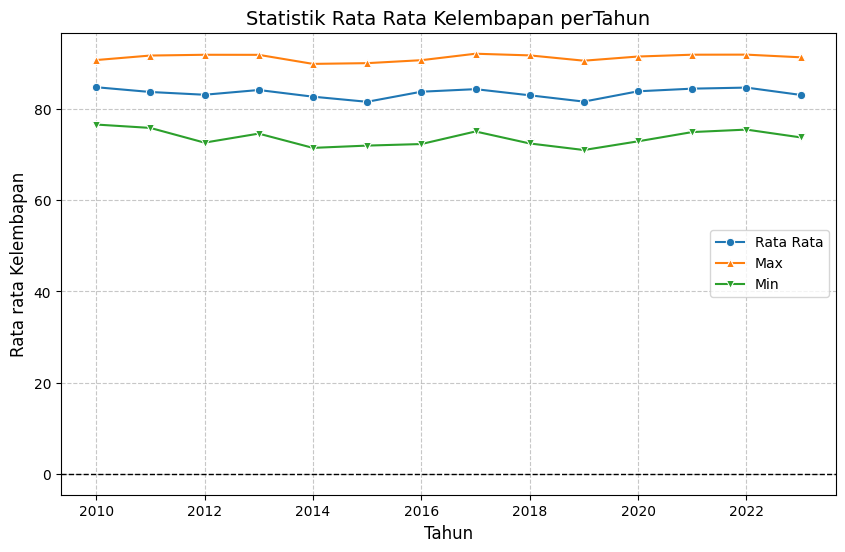

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/DATA/Iklim Lokal & Standarisasi.xlsx" "./Iklim_data.xlsx"

Kelembapan = pd.read_excel("Iklim_data.xlsx", sheet_name="Kelembapan", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = Kelembapan.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
Kelembapan = Kelembapan[Kelembapan[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in Kelembapan.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
Kelembapan[tahun_cols] = (
    Kelembapan[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = Kelembapan[tahun_cols].mean()
statistik["median"] = Kelembapan[tahun_cols].median()
statistik["Q1"] = Kelembapan[tahun_cols].quantile(0.25)
statistik["Q3"] = Kelembapan[tahun_cols].quantile(0.75)
statistik["min"] = Kelembapan[tahun_cols].min()
statistik["max"] = Kelembapan[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Ambil hanya kolom tahun dan provinsi
Kelembapan_clean = Kelembapan.loc[:, 'Nama Provinsi':]
Kelembapan_clean = Kelembapan_clean.set_index('Nama Provinsi')

# Pastikan hanya kolom angka
year_columns = [col for col in Kelembapan_clean.columns if str(col).isdigit()]
Kelembapan_numeric = Kelembapan_clean[year_columns].apply(pd.to_numeric, errors='coerce')

# Hitung statistik
summary_stats = pd.DataFrame({
    'Mean': Kelembapan_numeric.mean(axis=1),
    'Median': Kelembapan_numeric.median(axis=1),
    'Q1': Kelembapan_numeric.quantile(0.25, axis=1),
    'Q3': Kelembapan_numeric.quantile(0.75, axis=1),
    'Min': Kelembapan_numeric.min(axis=1),
    'Max': Kelembapan_numeric.max(axis=1)
})

# Tampilkan
print(summary_stats)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata Kelembapan perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Rata rata Kelembapan", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
           mean  median     Q1     Q3    min    max
2010  26.300909   26.53  25.99  27.34  21.58  28.09
2011  25.936970   26.23  25.60  26.96  21.04  27.71
2012  26.060530   26.30  25.67  27.26  21.21  28.01
2013  26.165758   26.49  25.79  27.19  21.44  27.99
2014  26.298939   26.60  25.96  27.27  21.49  28.19
2015  26.366894   26.58  26.16  27.36  21.40  28.11
2016  26.646818   26.95  26.32  27.79  21.89  28.38
2017  26.217727   26.35  25.84  27.14  21.39  28.02
2018  26.303636   26.53  25.86  27.30  21.36  28.29
2019  26.558788   26.78  26.22  27.65  21.62  28.56
2020  26.534470   26.86  26.31  27.57  21.81  28.32
2021  26.267576   26.45  25.97  27.19  21.49  28.05
2022  26.245682   26.51  25.94  27.26  21.52  27.95
2023  26.625682   26.74  26.24  27.63  21.77  28.50
                           Mean   Median        Q1         Q3     Min     Max
Nama Provinsi

<ipython-input-6-1084503804>:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


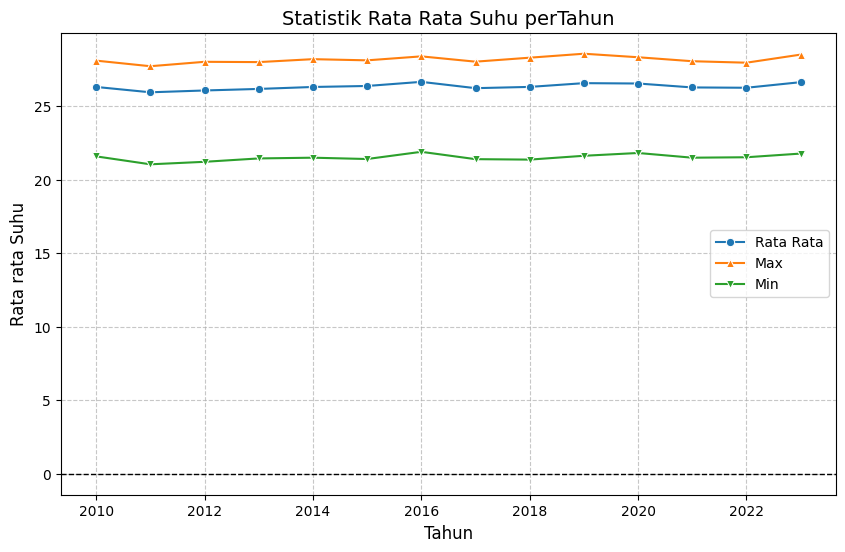

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/DATA/Iklim Lokal & Standarisasi.xlsx" "./Iklim_data.xlsx"

Suhu = pd.read_excel("Iklim_data.xlsx", sheet_name="Suhu", header=0)
# Ambil kolom nama provinsi (kolom pertama)
col_prov = Suhu.columns[2]

# Hapus baris 'INDONESIA' (jika ada)
Suhu = Suhu[Suhu[col_prov].astype(str).str.upper() != "INDONESIA"]

# Ambil kolom tahun (pastikan hanya kolom angka)
tahun_cols = [col for col in Suhu.columns if str(col).isdigit()]

# Bersihkan data: hilangkan karakter selain angka dan titik
Suhu[tahun_cols] = (
    Suhu[tahun_cols]
    .replace(r"[^\d.]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Hitung statistik
statistik = pd.DataFrame(index=tahun_cols)
statistik["mean"] = Suhu[tahun_cols].mean()
statistik["median"] = Suhu[tahun_cols].median()
statistik["Q1"] = Suhu[tahun_cols].quantile(0.25)
statistik["Q3"] = Suhu[tahun_cols].quantile(0.75)
statistik["min"] = Suhu[tahun_cols].min()
statistik["max"] = Suhu[tahun_cols].max()

# Tampilkan hasil
print(statistik)

# Ambil hanya kolom tahun dan provinsi
Suhu_clean = Suhu.loc[:, 'Nama Provinsi':]
Suhu_clean = Suhu_clean.set_index('Nama Provinsi')

# Pastikan hanya kolom angka
year_columns = [col for col in Suhu_clean.columns if str(col).isdigit()]
Suhu_numeric = Suhu_clean[year_columns].apply(pd.to_numeric, errors='coerce')

# Hitung statistik
summary_stats = pd.DataFrame({
    'Mean': Suhu_numeric.mean(axis=1),
    'Median': Suhu_numeric.median(axis=1),
    'Q1': Suhu_numeric.quantile(0.25, axis=1),
    'Q3': Suhu_numeric.quantile(0.75, axis=1),
    'Min': Suhu_numeric.min(axis=1),
    'Max': Suhu_numeric.max(axis=1)
})

# Tampilkan
print(summary_stats)

# Plot line chart untuk statistik tahunan
plt.figure(figsize=(10, 6))  # Ukuran figure

# Plot masing-masing statistik
sns.lineplot(x=statistik.index, y=statistik["mean"], label="Rata Rata", marker="o")
# sns.lineplot(x=statistik.index, y=statistik["median"], label="Median", marker="s")
sns.lineplot(x=statistik.index, y=statistik["max"], label="Max", marker="^")
sns.lineplot(x=statistik.index, y=statistik["min"], label="Min", marker="v")

# Tambahkan judul dan label sumbu
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # Garis nol untuk memisahkan nilai positif dan negatif
plt.title("Statistik Rata Rata Suhu perTahun", fontsize=14)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Rata rata Suhu", fontsize=12)

# Tambahkan legenda
plt.legend()

# Tambahkan grid untuk memperjelas garis
plt.grid(True, linestyle="--", alpha=0.7)

# Tampilkan plot
plt.show()